# 02 - LSM and CAP age x sex marginals (pooled 2017-2023)

Builds the survey-weighted age x sex marginals of **liver stiffness (LSM, kPa)**
and **controlled attenuation parameter (CAP, dB/m)** from the pooled parquet
written by notebook 01, and profiles the **fibrosis stage shares** (F0-F4) by
age and sex.

## What changed from the earlier version

- **Two variables.** CAP (hepatic steatosis) is profiled beside LSM.
- **Pooled sample.** 2017-Mar 2020 + 2021-Aug 2023, weights halved.
- **Stage shares, not just the F4 tail.** The project now needs the F1/F2/F3
  shares accurate, not only cirrhosis (F4). Stage cutoffs are the repo-standard
  **6 / 8 / 10 / 15 kPa** (F0<6, F1 6-8, F2 8-10, F3 10-15, F4>=15).
- **Top-coded age.** NHANES codes age 80 as 80+, so the oldest band is drawn
  open-ended.

## What we show

1. Overall shape of LSM and CAP (weighted, adults 18+).
2. Age x sex marginal mean/median for each variable, with paired-PSU jackknife
   95% CIs (following the project's error-bar convention).
3. Fibrosis stage-share profiles (F0-F4) by age x sex.
4. Steatosis prevalence (CAP >= gate) by age x sex.


In [1]:
import warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lsm_cap_fit as L
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

pool = pd.read_parquet(L.POOLED_PARQUET)
lsm = L.analysis_frame(pool, 'LSM')
cap = L.analysis_frame(pool, 'CAP')
lsm_ad = lsm[lsm['age_years'] >= 18].copy()
cap_ad = cap[cap['age_years'] >= 18].copy()
print(f'LSM adults 18+: {len(lsm_ad):,} | CAP adults 18+: {len(cap_ad):,}')

# 10-year display bands, open-ended 80+ (age is top-coded at 80).
DISPLAY_EDGES = [18, 30, 40, 50, 60, 70, 80]
def display_band(a):
    if a >= 80: return '80+'
    for lo in DISPLAY_EDGES[::-1]:
        if a >= lo: return f'{lo}-{lo + (12 if lo == 18 else 9)}'
    return None
BAND_LABELS = [f'{lo}-{lo + (12 if lo == 18 else 9)}' for lo in DISPLAY_EDGES[:-1]] + ['80+']
for d in (lsm_ad, cap_ad):
    d['band'] = d['age_years'].apply(display_band)


LSM adults 18+: 13,294 | CAP adults 18+: 13,292


## 1. Overall distribution shape (weighted, adults 18+)

LSM is heavily right-skewed with a long fibrosis tail; CAP is roughly symmetric.


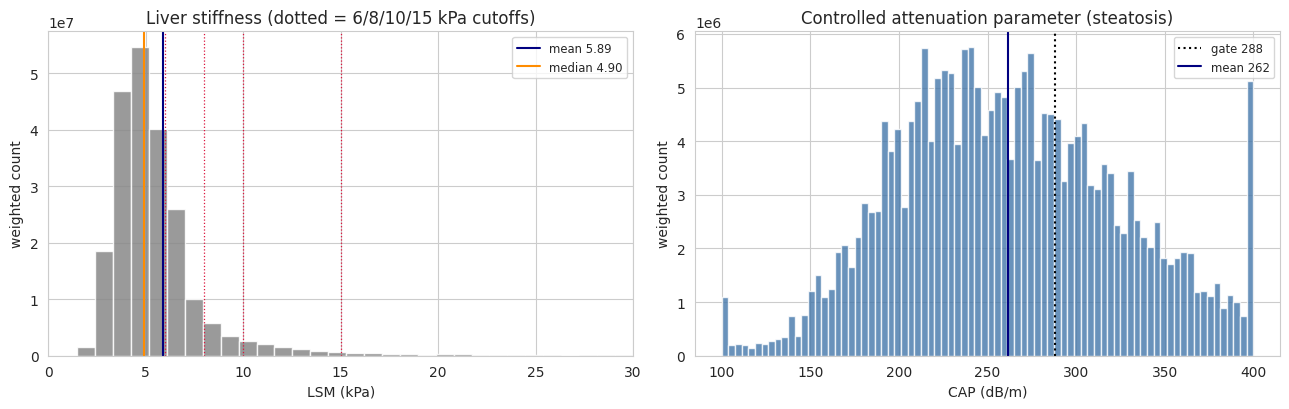

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
y = lsm_ad['LSM_KPA'].values; w = lsm_ad['MEC_WT_POOL'].values
axes[0].hist(y, bins=80, weights=w, color='#888', alpha=0.85)
for c in L.LSM_CUTOFFS:
    axes[0].axvline(c, color='crimson', linestyle=':', linewidth=0.9)
axes[0].axvline(L.w_mean(y, w), color='navy', label=f'mean {L.w_mean(y, w):.2f}')
axes[0].axvline(L.w_quantile(y, w, .5), color='darkorange', label=f'median {L.w_quantile(y, w, .5):.2f}')
axes[0].set_xlim(0, 30); axes[0].set_xlabel('LSM (kPa)'); axes[0].set_ylabel('weighted count')
axes[0].set_title('Liver stiffness (dotted = 6/8/10/15 kPa cutoffs)'); axes[0].legend(fontsize='small')

yc = cap_ad['CAP_DBM'].values; wc = cap_ad['MEC_WT_POOL'].values
axes[1].hist(yc, bins=80, weights=wc, color='#4477aa', alpha=0.8)
axes[1].axvline(L.CAP_STEATOSIS_GATE, color='black', linestyle=':', label=f'gate {L.CAP_STEATOSIS_GATE:.0f}')
axes[1].axvline(L.w_mean(yc, wc), color='navy', label=f'mean {L.w_mean(yc, wc):.0f}')
axes[1].set_xlabel('CAP (dB/m)'); axes[1].set_ylabel('weighted count')
axes[1].set_title('Controlled attenuation parameter (steatosis)'); axes[1].legend(fontsize='small')
fig.tight_layout(); plt.show()


## 2. Age x sex marginal with paired-PSU jackknife CIs

Weighted mean and median per (sex, band) with 95% CIs from a paired-PSU
jackknife. Because we pooled two cycles, the variance strata are made unique per
cycle (`cycle` x `SDMVSTRA`) so PSUs stay nested within their own design.


In [3]:
def paired_jackknife(sub, valcol, statistic):
    if len(sub) == 0:
        return np.nan, np.nan
    y = sub[valcol].values.astype(float)
    w = sub['MEC_WT_POOL'].values.astype(float)
    strata = (sub['cycle'].astype(str) + '_' + sub['SDMVSTRA'].astype(str)).values
    psu = sub['SDMVPSU'].astype('Int64').astype(int).values
    theta = statistic(y, w)
    var = 0.0
    for st in np.unique(strata):
        ins = strata == st
        psus = np.unique(psu[ins])
        if len(psus) < 2:
            continue
        for pj in psus:
            wr = w.copy()
            wr[ins & (psu == pj)] = 0.0
            wr[ins & (psu != pj)] *= 2.0
            if wr.sum() <= 0:
                continue
            var += (statistic(y, wr) - theta) ** 2
    return theta, float(np.sqrt(var))

def cell_summary(sub, valcol):
    mean, mse = paired_jackknife(sub, valcol, L.w_mean)
    med, medse = paired_jackknife(sub, valcol, lambda a, b: L.w_quantile(a, b, 0.5))
    return dict(n=len(sub), mean=mean, mean_se=mse, median=med, median_se=medse)

marg = {}
for name, frame, col in [('LSM', lsm_ad, 'LSM_KPA'), ('CAP', cap_ad, 'CAP_DBM')]:
    rows = []
    for sex in ['Female', 'Male']:
        for band in BAND_LABELS:
            sub = frame[(frame['sex'] == sex) & (frame['band'] == band)]
            d = cell_summary(sub, col); d.update(sex=sex, band=band)
            rows.append(d)
    marg[name] = pd.DataFrame(rows)
print('LSM marginal (kPa):')
print(marg['LSM'].round(2).to_string(index=False))
print()
print('CAP marginal (dB/m):')
print(marg['CAP'].round(1).to_string(index=False))


LSM marginal (kPa):
   n  mean  mean_se  median  median_se    sex  band
1145  4.71     0.11     4.5       0.17 Female 18-30
1048  5.24     0.27     4.4       0.00 Female 30-39
 994  5.21     0.17     4.5       0.39 Female 40-49
1143  6.17     0.34     5.1       0.22 Female 50-59
1437  5.79     0.24     4.8       0.23 Female 60-69
 804  5.76     0.17     5.0       0.60 Female 70-79
 328  5.62     0.23     5.0       0.21 Female   80+
1170  5.69     0.23     5.0       0.20   Male 18-30
 906  5.78     0.25     5.0       0.24   Male 30-39
 907  6.56     0.52     5.2       0.46   Male 40-49
 976  6.68     0.34     5.3       0.55   Male 50-59
1317  6.71     0.26     5.3       0.42   Male 60-69
 780  7.31     0.58     5.5       0.39   Male 70-79
 339  6.73     0.87     5.4       0.52   Male   80+

CAP marginal (dB/m):
   n  mean  mean_se  median  median_se    sex  band
1145 230.1      3.7   221.0        5.5 Female 18-30
1047 246.6      2.9   241.0        6.7 Female 30-39
 994 254.2      3.5   

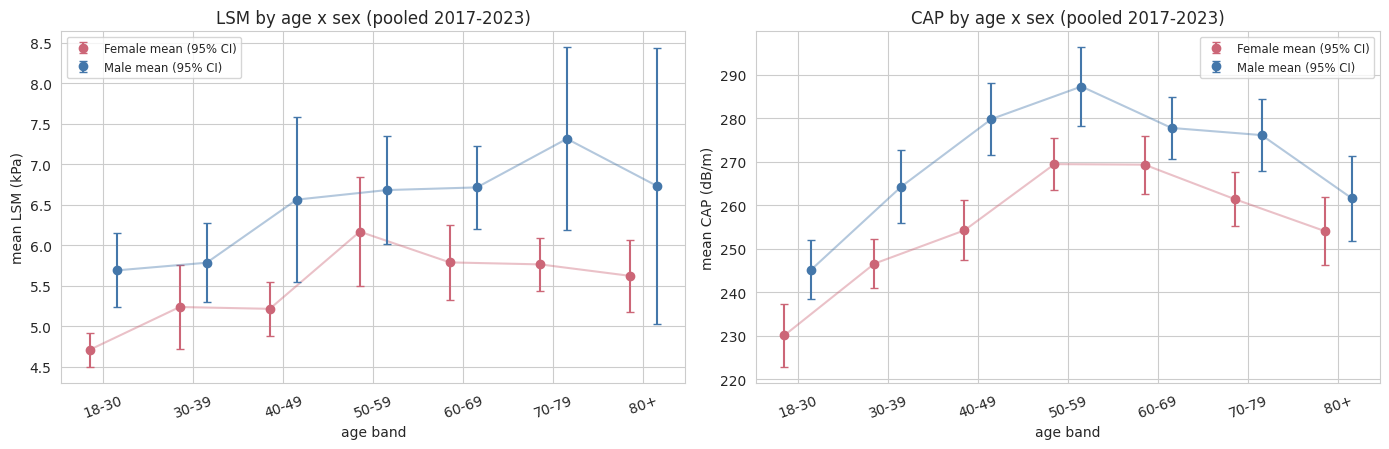

In [4]:
sex_colors = {'Female': '#cc6677', 'Male': '#4477aa'}
pos = {b: i for i, b in enumerate(BAND_LABELS)}
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
for ax, (name, unit) in zip(axes, [('LSM', 'kPa'), ('CAP', 'dB/m')]):
    t = marg[name]
    for k, sex in enumerate(['Female', 'Male']):
        s = t[t['sex'] == sex]
        x = s['band'].map(pos) + (k - 0.5) * 0.3
        ax.errorbar(x, s['mean'], yerr=1.96 * s['mean_se'], fmt='o', capsize=3,
                    color=sex_colors[sex], label=f'{sex} mean (95% CI)')
        ax.plot(x, s['mean'], '-', color=sex_colors[sex], alpha=0.4)
    ax.set_xticks(range(len(BAND_LABELS))); ax.set_xticklabels(BAND_LABELS, rotation=20)
    ax.set_xlabel('age band'); ax.set_ylabel(f'mean {name} ({unit})')
    ax.set_title(f'{name} by age x sex (pooled 2017-2023)'); ax.legend(fontsize='small')
fig.tight_layout(); plt.show()


## 3. Fibrosis stage-share profiles (the load-bearing quantity)

For each (sex, band) the weighted share of adults in each fibrosis stage F0-F4.
This is what the simulation routes on -- and what the project now needs accurate
at F1/F2/F3, not only F4. Note F2 (8-10 kPa, a narrow 2-kPa band) often carries
*less* mass than F3 (10-15 kPa, a wider band), a shoulder a single lognormal
struggles to reproduce (quantified in notebook 06).


   sex  band    n   F0   F1  F2  F3  F4
Female 18-30 1145 85.7 10.6 2.3 1.2 0.2
Female 30-39 1048 80.7 12.6 3.3 2.3 1.1
Female 40-49  994 76.9 14.4 4.3 3.3 1.1
Female 50-59 1143 69.7 18.9 4.7 3.7 3.0
Female 60-69 1437 71.9 16.4 4.7 4.8 2.1
Female 70-79  804 70.9 18.1 5.1 3.2 2.8
Female   80+  328 70.7 19.8 4.5 2.1 2.9
  Male 18-30 1170 74.4 16.8 4.3 3.0 1.5
  Male 30-39  906 73.6 17.5 4.0 2.9 1.9
  Male 40-49  907 65.2 23.0 4.7 3.6 3.5
  Male 50-59  976 61.6 23.2 5.4 5.3 4.5
  Male 60-69 1317 61.7 22.9 5.7 6.2 3.6
  Male 70-79  780 59.0 24.0 5.6 6.9 4.5
  Male   80+  339 62.2 20.2 8.4 5.9 3.3


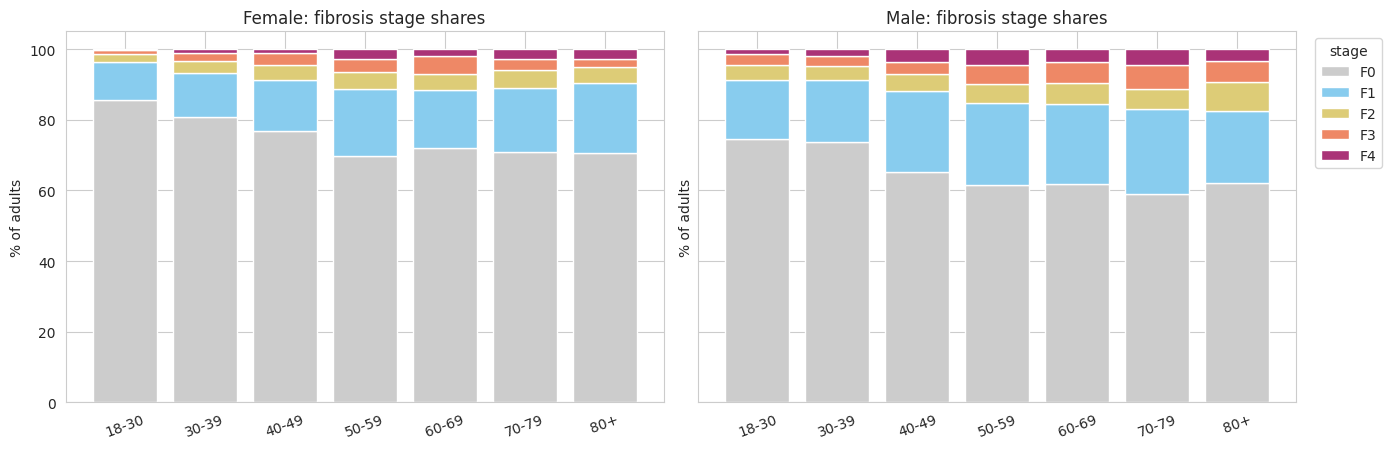

In [5]:
rows = []
for sex in ['Female', 'Male']:
    for band in BAND_LABELS:
        sub = lsm_ad[(lsm_ad['sex'] == sex) & (lsm_ad['band'] == band)]
        if len(sub) < 30:
            continue
        sh = L.empirical_stage_shares(sub['LSM_KPA'].values, sub['MEC_WT_POOL'].values, L.LSM_CUTOFFS)
        rows.append(dict(sex=sex, band=band, n=len(sub),
                         **{st: sh[i] for i, st in enumerate(L.LSM_STAGES)}))
stage = pd.DataFrame(rows)
print((stage.assign(**{s: (stage[s] * 100).round(1) for s in L.LSM_STAGES})).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.6), sharey=True)
stage_colors = ['#cccccc', '#88ccee', '#ddcc77', '#ee8866', '#aa3377']
for ax, sex in zip(axes, ['Female', 'Male']):
    s = stage[stage['sex'] == sex].set_index('band').reindex(BAND_LABELS).dropna(how='all')
    bottom = np.zeros(len(s))
    for st, c in zip(L.LSM_STAGES, stage_colors):
        ax.bar(range(len(s)), s[st].values * 100, bottom=bottom, color=c, label=st)
        bottom += s[st].values * 100
    ax.set_xticks(range(len(s))); ax.set_xticklabels(s.index, rotation=20)
    ax.set_title(f'{sex}: fibrosis stage shares'); ax.set_ylabel('% of adults')
axes[1].legend(title='stage', bbox_to_anchor=(1.02, 1), loc='upper left')
fig.tight_layout(); plt.show()


## 4. Steatosis prevalence (CAP) by age x sex

Share of adults with CAP at or above the steatosis gate (288 dB/m). CAP itself
is delivered downstream as a moment-matched distribution (notebook 04); this
grade view is descriptive.


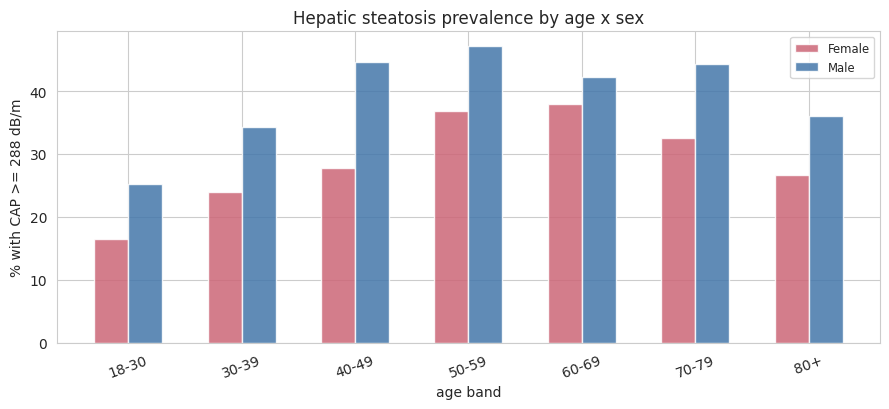

   sex  band    n  steatosis
Female 18-30 1145       16.4
Female 30-39 1047       24.0
Female 40-49  994       27.8
Female 50-59 1143       36.8
Female 60-69 1437       38.0
Female 70-79  804       32.6
Female   80+  328       26.6
  Male 18-30 1169       25.2
  Male 30-39  906       34.3
  Male 40-49  907       44.6
  Male 50-59  976       47.1
  Male 60-69 1317       42.2
  Male 70-79  780       44.4
  Male   80+  339       36.0


In [6]:
rows = []
for sex in ['Female', 'Male']:
    for band in BAND_LABELS:
        sub = cap_ad[(cap_ad['sex'] == sex) & (cap_ad['band'] == band)]
        if len(sub) < 30:
            continue
        p = L.w_share_above(sub['CAP_DBM'].values, sub['MEC_WT_POOL'].values, L.CAP_STEATOSIS_GATE)
        rows.append(dict(sex=sex, band=band, n=len(sub), steatosis=p))
steat = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(9, 4.2))
for k, sex in enumerate(['Female', 'Male']):
    s = steat[steat['sex'] == sex]
    x = s['band'].map(pos) + (k - 0.5) * 0.3
    ax.bar(x, s['steatosis'] * 100, width=0.3, color=sex_colors[sex], label=sex, alpha=0.85)
ax.set_xticks(range(len(BAND_LABELS))); ax.set_xticklabels(BAND_LABELS, rotation=20)
ax.set_ylabel(f'% with CAP >= {L.CAP_STEATOSIS_GATE:.0f} dB/m'); ax.set_xlabel('age band')
ax.set_title('Hepatic steatosis prevalence by age x sex'); ax.legend(fontsize='small')
fig.tight_layout(); plt.show()
print(steat.assign(steatosis=(steat['steatosis'] * 100).round(1)).to_string(index=False))


## Takeaways

- LSM mean/median and stage shares both climb with age and run higher in men --
  more between-cell variation than a single scalar can carry, which is why the
  loader gets per-(sex, age) parameters (notebook 04).
- CAP varies far less by age and sex; a per-cell moment-matched distribution is
  adequate.
- The F1/F2/F3 shares are substantial (F1 alone is 15-25% of older adults),
  making their accuracy -- not just the F4 tail -- the right calibration target.

**Caveats:** pooled-cycle weights are halved (no official NCHS recipe for
combining the pre-pandemic file with later cycles); complete-exam-only selection
(~7% of MEC adults lack a valid FibroScan) is uncorrected; age is top-coded at 80.
